# Heatwave Detection on CMIP6 GCMs

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import pickle
import numpy as np
import pandas as pd
import xarray as xr


# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

c:\Users\marti\Desktop\data\hw_extra


In [3]:
from indices import get_heatwaves_indices, transform_time_label

In [4]:
colors = {
    "ssp126" : "blue",
    "ssp245" : "green",
    "ssp370" : "brown",
    "ssp585" : "red",
    "historical" : "gray"
}
units_hws = {
    "hwn" : "heatwaves",
    "hwf" : "days",
    "hwd" : "days",
    "hwm" : "°K/day",
    "hwa" : "°K",
    "hwi" : "°K",
    "hwmeani": "°K",
    "hwmaxi": "°K",
    "hwmeand": "days"
}

## Load data

In [5]:
hws_chile = pd.read_csv("data/local_data/monthly/hws_chile_new_agg.csv")

hws_chile["time"] = pd.to_datetime(hws_chile["Unnamed: 0"],format='%Y-%m')
hws_chile.set_index('time', inplace=True)
hws_chile.drop(columns="Unnamed: 0", inplace=True)
# hws_chile = hws_chile[["hwn", "hwf", "hwd", "hwm", "hwa", "hwmeani"]]
hws_chile

,hwn,hwf,hwd,hwm,hwa,hwmeand,hwi,hwmaxi,hwmeani
time,,,,,,,,,
1971-01-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-02-01,0.2,0.7,0.7,0.447148,0.807169,0.7,1.508644,1.508644,1.508644
1971-03-01,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
1971-04-01,0.2,0.6,0.6,0.637038,0.982249,0.6,1.911113,1.911113,1.911113
1971-05-01,0.1,0.3,0.3,0.555671,0.901254,0.3,1.667013,1.667013,1.667013
...,...,...,...,...,...,...,...,...,...
2024-08-01,0.4,1.3,1.3,0.759857,1.294393,1.3,2.501609,2.501609,2.501609
2024-09-01,0.2,0.6,0.6,0.367076,0.617588,0.6,1.101228,1.101228,1.101228
2024-10-01,0.4,1.2,0.9,0.853280,1.349775,0.9,3.552305,2.792164,2.559840


In [6]:
path_stations_detection = "data/03_primary/events/cmip6/"
scenarios = ['historical', 'ssp126', 'ssp245', 'ssp370', 'ssp585']
cmip6_models = ['MPI-ESM1-2-HR', 'MRI-ESM2-0', 'GFDL-ESM4', 'EC-Earth3', 'MIROC6', 'AWI-CM-1-1-MR', 'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-LR', 'ACCESS-ESM1-5', 'IPSL-CM6A-LR']
stat_list = [
    "330007",
    "330020",
    "330030",
    "340031",
    "360011",
    "360019",
    "380013",
    "390006",
    "400009",
    "410005",
]
hw_model_scenario_station_df = {
    model: {
        scenario: {
            station: xr.open_dataset(f"{path_stations_detection}/{model}/{scenario}/station_detection/{station}/default.nc").to_dataframe() for station in stat_list
        } for scenario in scenarios
    } for model in cmip6_models
}

In [7]:
path_stations_detection = "data/03_primary/events/era5/"
hws_era5_df ={
            station: xr.open_dataset(f"{path_stations_detection}/station_detection/{station}/default.nc").to_dataframe() for station in stat_list
        } 

In [8]:
hws_chile_model_scenario_yearly = {}
indices = ("hwn", "hwf", "hwd", "hwm", "hwa", "hwmeand", "hwi", "hwmaxi", "hwmeani")
for model_name, dict_scenarios in hw_model_scenario_station_df.items():
    scenario_stat_hws = {}
    for scenario, dict_stations in dict_scenarios.items():
        stations_indices = {}
        if scenario == "historical":
            target_years = (1970, 2014)
        else:
            target_years = (2015, 2100)

        # Get yearly indices for 10 stations
        for station_name, hw in dict_stations.items():
            stations_indices[station_name] = get_heatwaves_indices(hw, target_years, time_scale="year")
            stations_indices[station_name].index = pd.DatetimeIndex(stations_indices[station_name].index)

        # Concat stations indices
        hws_all_stats = pd.concat(list(stations_indices.values()), axis=1)
        hws_chile_df = pd.DataFrame(columns=indices, index=hws_all_stats.index)

        for index in indices:
            if index in ["hwn", "hwf", "hwi"]:
                hws_chile_df[index] = hws_all_stats[index].mean(axis=1)
            elif index in ["hwd", "hwa", "hwmaxi"]:
                hws_chile_df[index] = hws_all_stats[index].max(axis=1)
            elif index == "hwmeand":
                hws_chile_df[index] = hws_all_stats["hwf"].sum(axis=1) / hws_all_stats["hwn"].sum(axis=1)
            elif index == "hwm":
                hws_chile_df[index] = hws_all_stats["hwi"].sum(axis=1) / hws_all_stats["hwf"].sum(axis=1)
            elif index == "hwmeani":
                hws_chile_df[index] = hws_all_stats["hwi"].sum(axis=1) / hws_all_stats["hwn"].sum(axis=1)

        hws_chile_df = hws_chile_df.fillna(0.0)
        scenario_stat_hws[scenario] = hws_chile_df
    hws_chile_model_scenario_yearly[model_name] = scenario_stat_hws

In [9]:
meteochile_yearly = transform_time_label(hws_chile, "year")

## CMIP6 Detection

In [10]:
hw_mean_scenario = {}
hw_std_scenario = {}
models = list(hws_chile_model_scenario_yearly.keys())
for scenario in scenarios:
    
    all_models = pd.concat([hws_chile_model_scenario_yearly[model][scenario] for model in models], axis=1)
    df_mean_scenario = pd.DataFrame(columns=indices, index=hws_chile_model_scenario_yearly["EC-Earth3"][scenario].index)
    df_std_scenario = pd.DataFrame(columns=indices, index=hws_chile_model_scenario_yearly["EC-Earth3"][scenario].index)
    for index in indices:
        df_mean_scenario[index] = all_models[index].mean(axis=1)
        df_std_scenario[index] = all_models[index].std(axis=1)

    hw_mean_scenario[scenario] = df_mean_scenario
    hw_std_scenario[scenario] = df_std_scenario

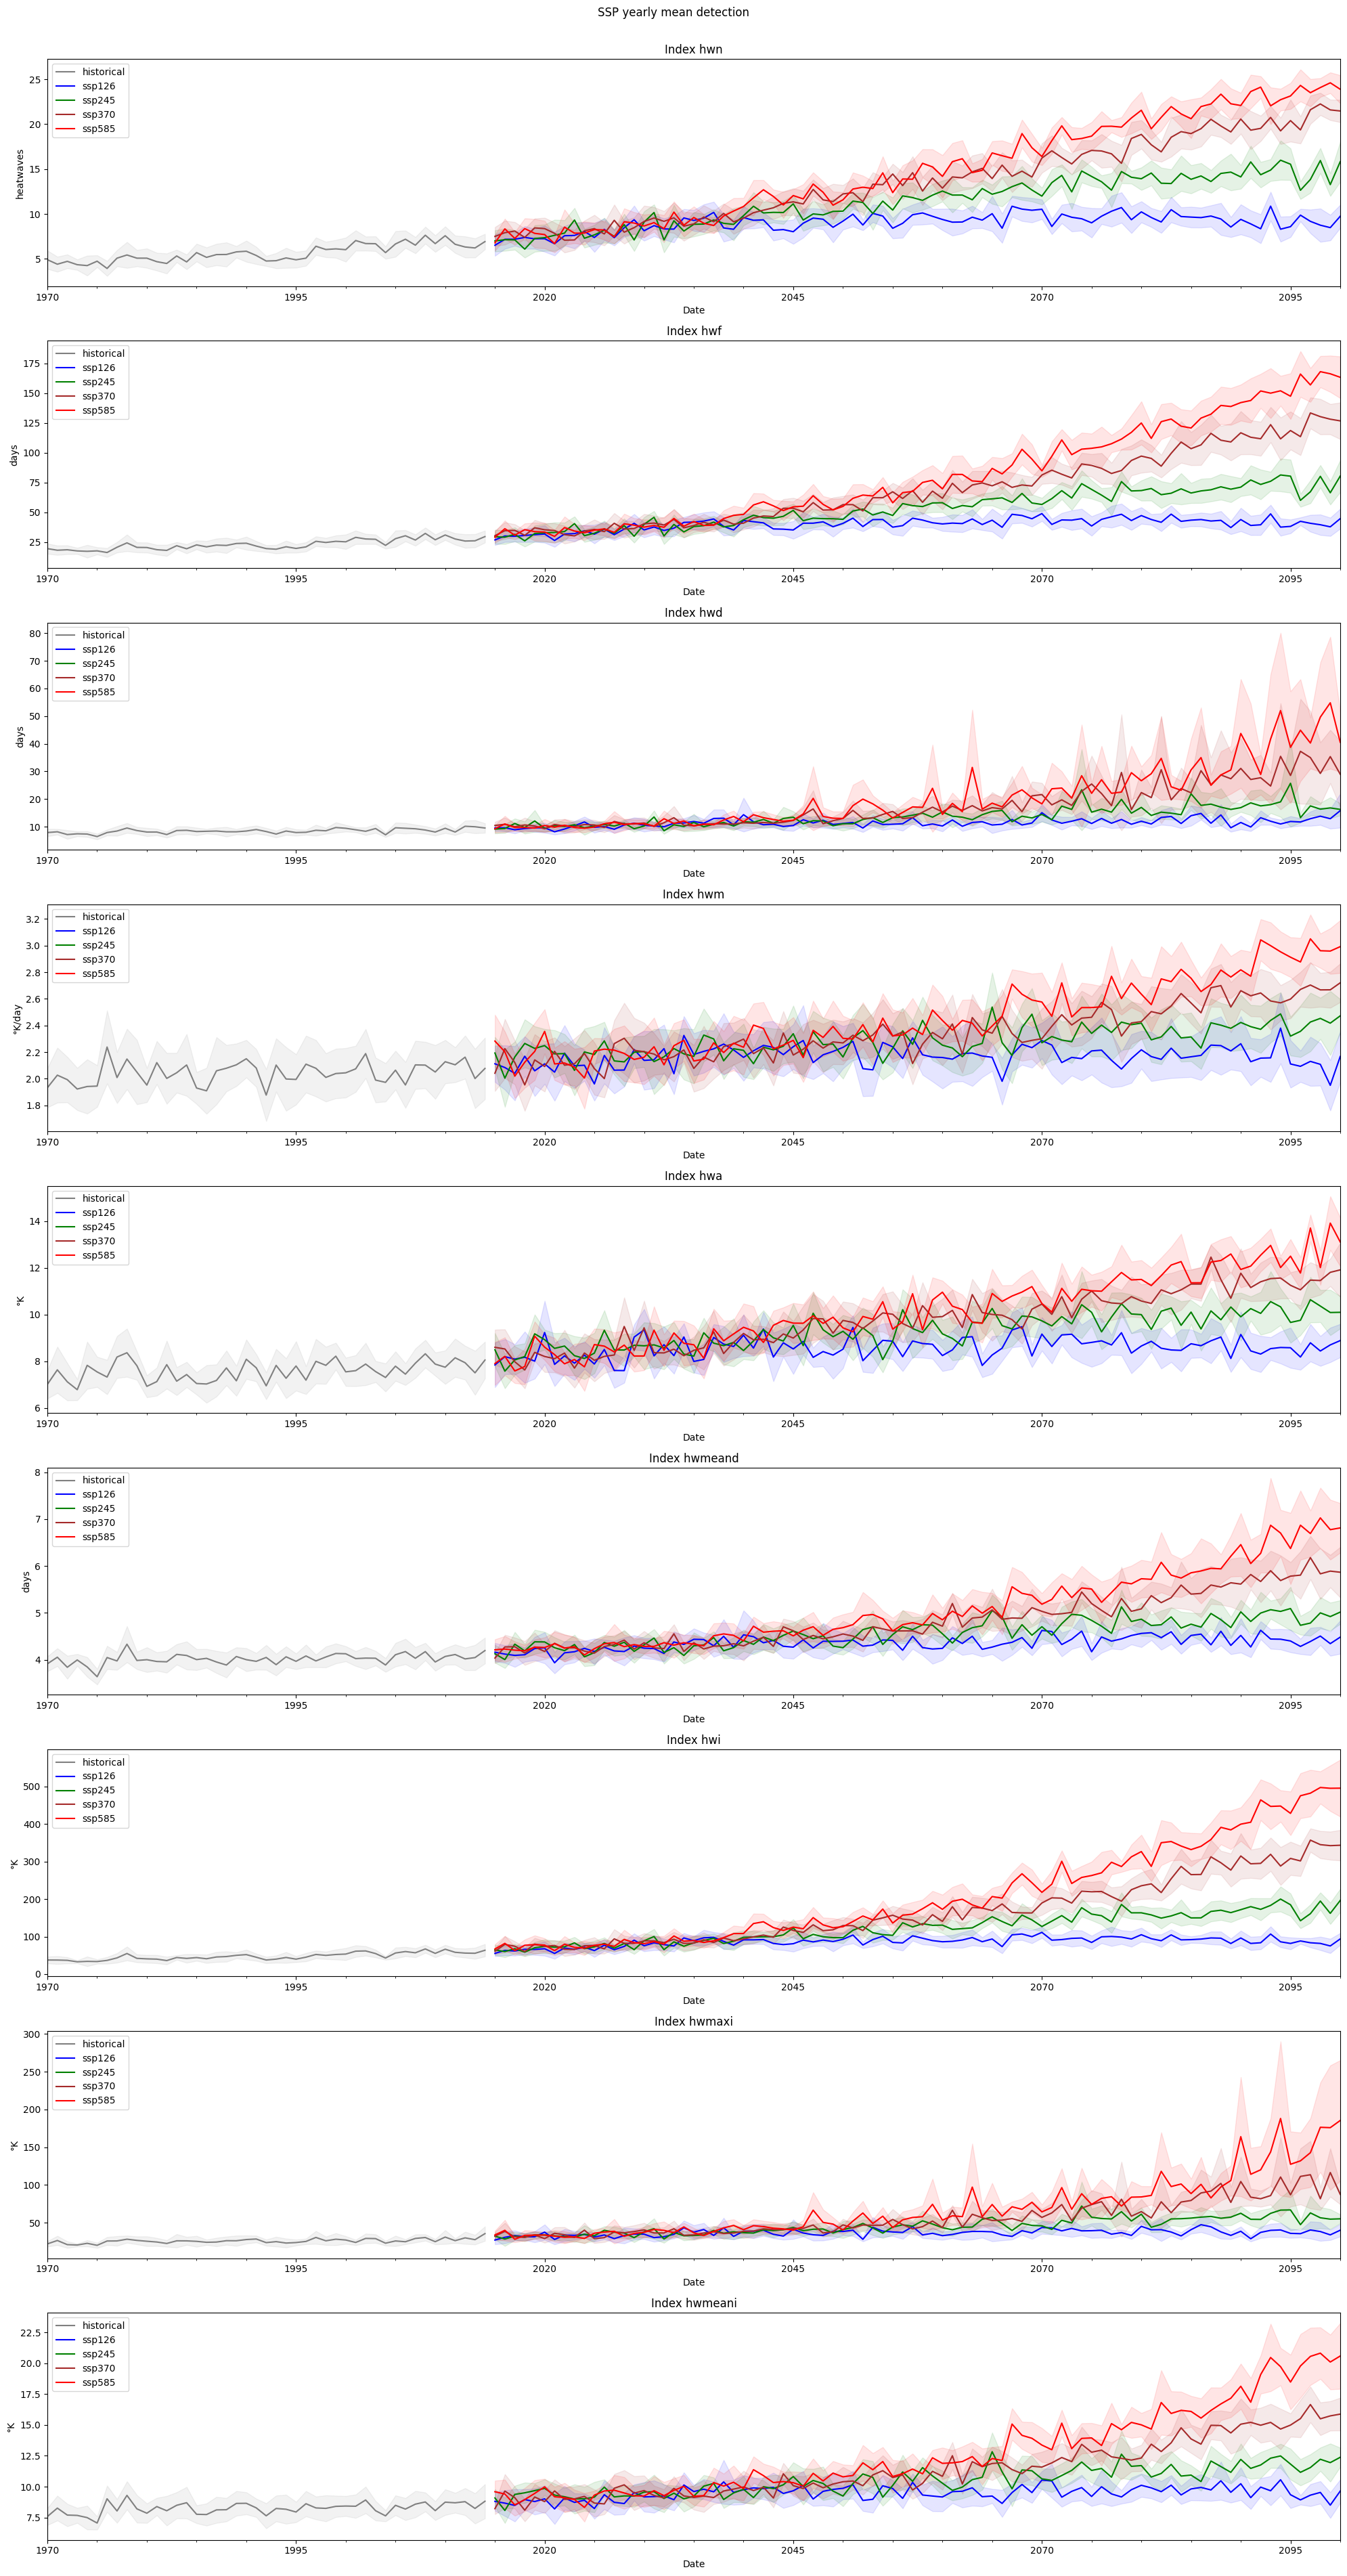

In [11]:
# model = "decadal_then_mean"
fig, axs = plt.subplots(len(indices), figsize=(20, 40))

for i, index in enumerate(indices):
    for scenario in scenarios:
        hw_mean_scenario[scenario].plot(y=index, ax=axs[i], label=scenario, color=colors[scenario])
        values = hw_mean_scenario[scenario][index].values
        std = hw_std_scenario[scenario][index].values
        axs[i].fill_between(
            hw_mean_scenario[scenario].index,  values - 0.5*std , values + 0.5*std, alpha=0.1, color=colors[scenario]
        )
    axs[i].set_title(f"Index {index}")
    axs[i].set_ylabel(f"{units_hws[index]}")
    axs[i].set_xlabel("Date")
    axs[i].legend()
fig.tight_layout(rect=[0, 0.03, 1, 0.97]) 
fig.suptitle(f"SSP yearly mean detection")
plt.show()